--- Part 1: Installing and Importing Libraries ---
Libraries installed and imported successfully.

--- Part 2: Loading and Cleaning Data ---
Dataset loaded. Shape: (303, 14)
Checking for missing values ('?'):
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


--- Part 3: Splitting Data (Where Training & Evaluation sets separate) ---
Training Set (X_train): (242, 13) samples
Evaluation Set (X_test): (61, 13) samples


--- Part 4: Advanced Preprocessing (Imputation & Scaling) ---
Applying KNN Imputer to fill missing values...
Applying StandardScaler...


--- Part 5: Model Training & Evaluation ---
--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85  

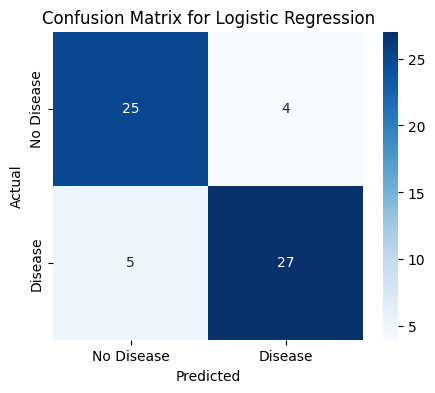

--- KNN (k=7) ---
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



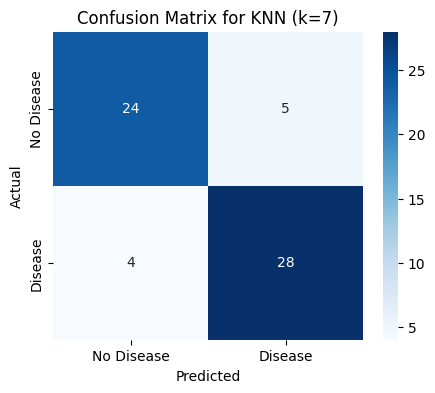

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.84      0.93      0.89        29
           1       0.93      0.84      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



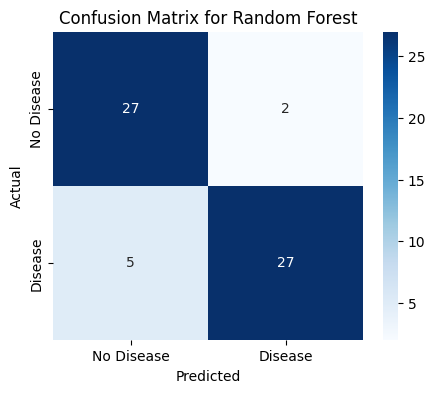

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:56:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost (Champion) ---
              precision    recall  f1-score   support

           0       0.81      0.86      0.83        29
           1       0.87      0.81      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



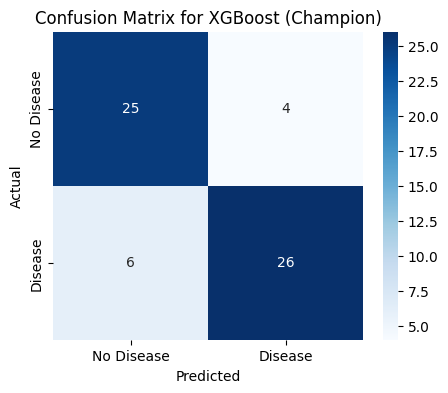


--- Final Performance Report ---
                     Accuracy  Precision   Recall  F1-Score
Random Forest        0.885246   0.931034  0.84375  0.885246
Logistic Regression  0.852459   0.870968  0.84375  0.857143
KNN (k=7)            0.852459   0.848485  0.87500  0.861538
XGBoost (Champion)   0.836066   0.866667  0.81250  0.838710


--- Part 6: Novelty - Explaining the BEST Model (XGBoost) ---


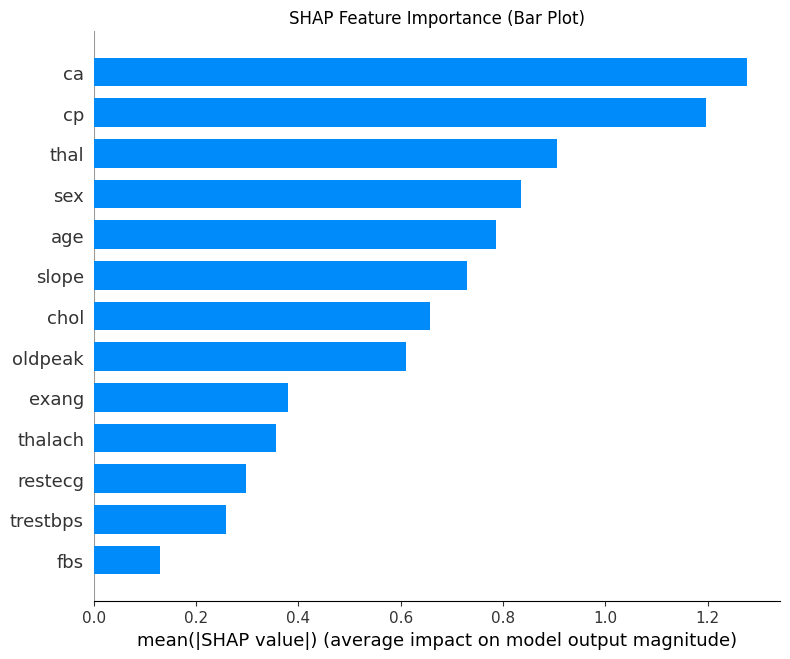

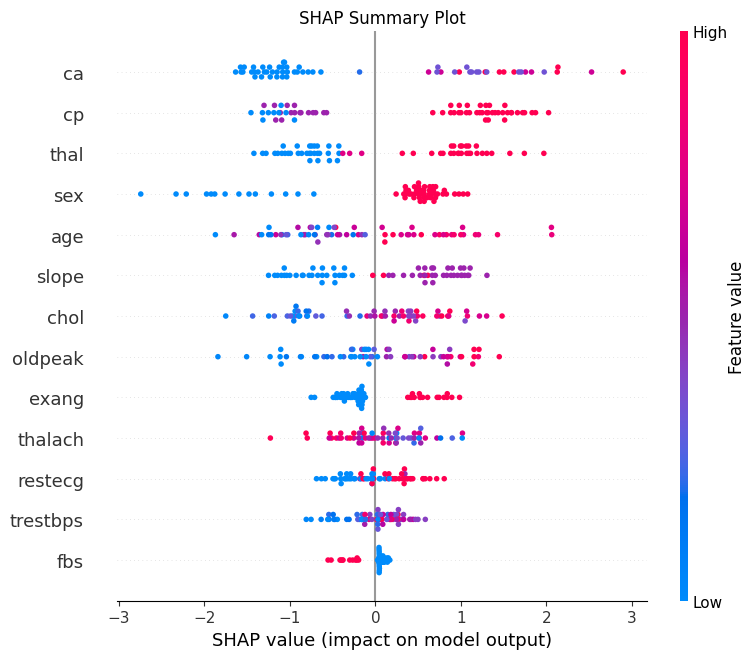

Explaining the first patient in the Evaluation Set:


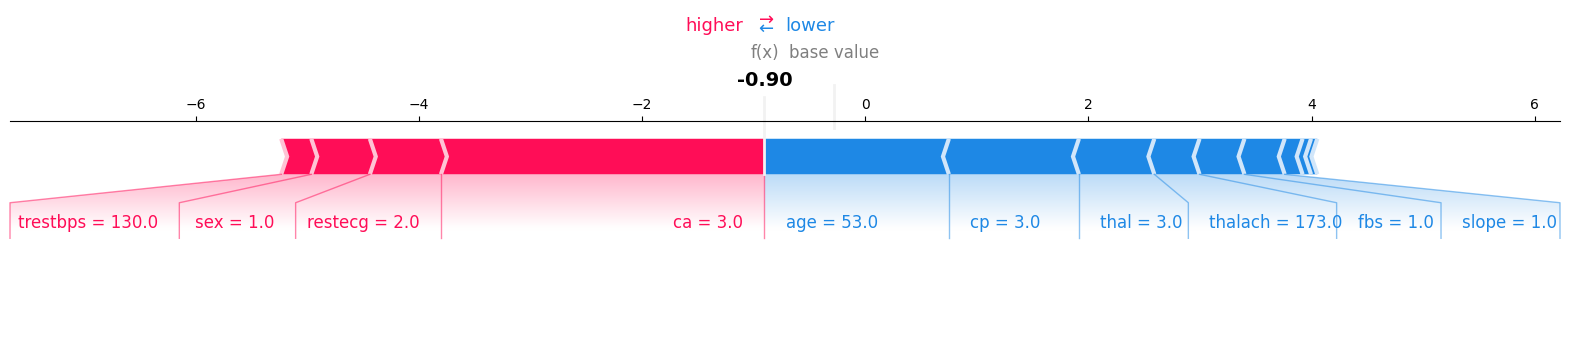

In [ ]:
# --- PART 1: SETUP AND LIBRARIES ---
print("--- Part 1: Installing and Importing Libraries ---")

# Install necessary libraries (SHAP and XGBoost are not default in Colab)
!pip install shap xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap  # For Explainable AI (XAI)

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer # Novelty: Advanced Imputation

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier # Novelty: Champion Model

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

print("Libraries installed and imported successfully.\n")

# --- PART 2: DATA LOADING AND CLEANING ---
print("--- Part 2: Loading and Cleaning Data ---")

# 1. URL for the ORIGINAL, messy UCI dataset (303 samples, contains '?')
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# 2. Define column names (since the file has no header)
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# 3. Load data
df = pd.read_csv(url, header=None, names=column_names, na_values='?')

# 4. Fix Target (Convert 0-4 to Binary 0/1)
df['target'] = (df['target'] > 0).astype(int)

print(f"Dataset loaded. Shape: {df.shape}")
print("Checking for missing values ('?'):")
print(df.isnull().sum())
print("\n")


# --- PART 3: TRAIN/TEST SEPARATION (CRITICAL STEP) ---
print("--- Part 3: Splitting Data (Where Training & Evaluation sets separate) ---")

# Define Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

# ===> THIS IS THE SEPARATION LINE <===
# test_size=0.20 means 20% is for Evaluation, 80% is for Training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training Set (X_train): {X_train.shape} samples")
print(f"Evaluation Set (X_test): {X_test.shape} samples")
print("\n")


# --- PART 4: ADVANCED PREPROCESSING (IMPUTATION & SCALING) ---
print("--- Part 4: Advanced Preprocessing (Imputation & Scaling) ---")

# 4.1 NOVELTY: Imputation using KNNImputer
# IMPORTANT: We .fit() ONLY on X_train to avoid 'Data Leakage'
print("Applying KNN Imputer to fill missing values...")
imputer = KNNImputer(n_neighbors=5)

# Fit on Train, Transform Train
X_train_imputed = imputer.fit_transform(X_train)
# Transform Test (using patterns learned from Train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame (to keep column names for SHAP later)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X.columns)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X.columns)

# 4.2 Scaling (Required for LR and KNN)
print("Applying StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)
print("\n")


# --- PART 5: MODEL TRAINING & EVALUATION ---
print("--- Part 5: Model Training & Evaluation ---")

results = {}

def evaluate_model(name, model, X_test_data, y_test_data):
    """Trains, predicts, and prints results."""
    # Predictions are made on the Evaluation Set (X_test_data)
    y_pred = model.predict(X_test_data)

    acc = accuracy_score(y_test_data, y_pred)
    pre = precision_score(y_test_data, y_pred)
    rec = recall_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred)

    results[name] = {'Accuracy': acc, 'Precision': pre, 'Recall': rec, 'F1-Score': f1}

    print(f"--- {name} ---")
    print(classification_report(y_test_data, y_pred))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test_data, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Model 1: Logistic Regression (uses SCALED data)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
evaluate_model('Logistic Regression', lr, X_test_scaled, y_test)

# Model 2: KNN (uses SCALED data)
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
evaluate_model('KNN (k=7)', knn, X_test_scaled, y_test)

# Model 3: Random Forest (uses IMPUTED data, scaling not needed)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_imputed, y_train)
evaluate_model('Random Forest', rf, X_test_imputed, y_test)

# Model 4: XGBoost (The Novel/Champion Model)
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_imputed, y_train)
evaluate_model('XGBoost (Champion)', xgb, X_test_imputed, y_test)


# --- FINAL PERFORMANCE REPORT ---
print("\n--- Final Performance Report ---")
results_df = pd.DataFrame(results).T.sort_values(by='Accuracy', ascending=False)
print(results_df)
print("\n")


# --- PART 6: NOVELTY - EXPLAINABLE AI (XAI) WITH SHAP ---
print("--- Part 6: Novelty - Explaining the BEST Model (XGBoost) ---")

# 1. Create Explainer
explainer = shap.TreeExplainer(xgb)

# 2. Calculate SHAP values on the Evaluation Set
shap_values = explainer.shap_values(X_test_imputed)

# 3. Plot Feature Importance
plt.title("SHAP Feature Importance (Bar Plot)")
shap.summary_plot(shap_values, X_test_imputed, plot_type="bar")

# 4. Plot Summary (Red/Blue dots)
plt.title("SHAP Summary Plot")
shap.summary_plot(shap_values, X_test_imputed)

# 5. Force Plot (Single Patient Explanation)
print("Explaining the first patient in the Evaluation Set:")
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test_imputed.iloc[0,:], matplotlib=True)